# DSAN 6600 - 01_data_cleaning.ipynb

Works on loading and cleaning the data, creating the male and female test sets, dataset access notes, and basic EDA.

### Dataset Access Notes

PTB-XL v1.0.3 — PhysioNet. 21,799 clinical 12-lead ECGs from 18,869 patients, 10 seconds each, at 100 Hz and 500 Hz.

Source:	https://physionet.org/content/ptb-xl/1.0.3/

Size:	1.7 GB zipped / 3.0 GB unzipped; we use the 100 Hz subset

License:	Creative Commons Attribution 4.0 — open access, no credentialing
Reading:	wfdb Python package

Why it fits. sex and age on every record — the two variables our design needs. strat_fold gives 10 stratified folds that keep each patient's records together, so patient-level separation is handled for us. Folds 9–10 received human validation and are our test set.

Access.

```bash
wget -r -N -c -np https://physionet.org/files/ptb-xl/1.0.3/
pip install wfdb
```

Data is gitignored. The repo carries code and the metadata CSV only, so anyone can clone and reproduce the pull in one line.

In [2]:
import ast
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = '../data/'
os.makedirs('../figures', exist_ok=True)

def save(name):
    plt.savefig(f'../figures/{name}.png', dpi=150, bbox_inches='tight')

In [3]:
df = pd.read_csv(PATH + 'ptbxl_database.csv', index_col='ecg_id')
print(df.shape)
df.head()

(21799, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


### Cleaning Data

We checked the dataset for missing values, duplicates, and incorrect/invalid values. Most importantly, the sex and age variables were standardized across the dataset. 

In [4]:
print(df.duplicated().sum())
print(df.isna().sum().sort_values(ascending=False))

0
electrodes_problems             21769
infarction_stadium2             21696
pacemaker                       21508
burst_noise                     21186
baseline_drift                  20201
extra_beats                     19850
static_noise                    18539
infarction_stadium1             16187
height                          14825
weight                          12378
validated_by                     9378
heart_axis                       8468
nurse                            1473
site                               17
strat_fold                          0
validated_by_human                  0
filename_lr                         0
patient_id                          0
initial_autogenerated_report        0
second_opinion                      0
age                                 0
scp_codes                           0
report                              0
recording_date                      0
device                              0
sex                                 0
filename_h

In [5]:
print(df["sex"].value_counts())

df["sex_label"] = df["sex"].replace({0: "male", 1: "female"})
print(df["sex_label"].value_counts())

df.head()

sex
0    11354
1    10445
Name: count, dtype: int64
sex_label
male      11354
female    10445
Name: count, dtype: int64


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,sex_label
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,female
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,male
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,female
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,male
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,female


Ages above 89 are stored as 300 for privacy. We keep patients aged 20–85 and remove the 300s and the children in the data.

In [6]:
df_len = len(df)
df = df[(df["age"] >= 20) & (df["age"] <= 85)].copy()
print(f"{df_len} -> {len(df)} records after age filter")

df["age_band"] = pd.cut(df["age"], [19, 39, 60, 85], labels=["<40", "40-60", ">60"])
df["age"].describe()

21799 -> 20370 records after age filter


count    20370.000000
mean        59.641532
std         15.153617
min         20.000000
25%         50.000000
50%         61.000000
75%         71.000000
max         85.000000
Name: age, dtype: float64

In [7]:
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

scp = pd.read_csv(PATH + 'scp_statements.csv', index_col=0)
scp = scp[scp['diagnostic'] == 1]

def get_labels(codes):
    return sorted({scp.loc[c, 'diagnostic_class'] for c in codes if c in scp.index})

df['labels'] = df['scp_codes'].apply(get_labels)

CLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for c in CLASSES:
    df[c] = df['labels'].apply(lambda x: c in x).astype(int)

print('No diagnostic label:', (df['labels'].apply(len) == 0).sum(), 'records (rhythm/form codes only; dropped before training)')
df[CLASSES].sum()

No diagnostic label: 378 records (rhythm/form codes only; dropped before training)


NORM    8964
MI      5093
STTC    4824
CD      4464
HYP     2460
dtype: int64

### Male and Female Test Sets

Folds 9 and 10 are reserved for evaluation only. They were all validated by a human cardiologist, so they have the highest-quality labels. The test set is split by sex so every model can be evaluated on men and women separately.

In [8]:
test_df = df[df["strat_fold"] >= 9]
male_test = test_df[test_df["sex"] == 0]
female_test = test_df[test_df["sex"] == 1]

print("Test set:", len(test_df))
print("Male:", len(male_test))
print("Female:", len(female_test))

Test set: 4048
Male: 2177
Female: 1871


### EDA: Counts by Sex

In [9]:
sex_counts = df["sex_label"].value_counts()
print(sex_counts)

sex_label
male      10870
female     9500
Name: count, dtype: int64


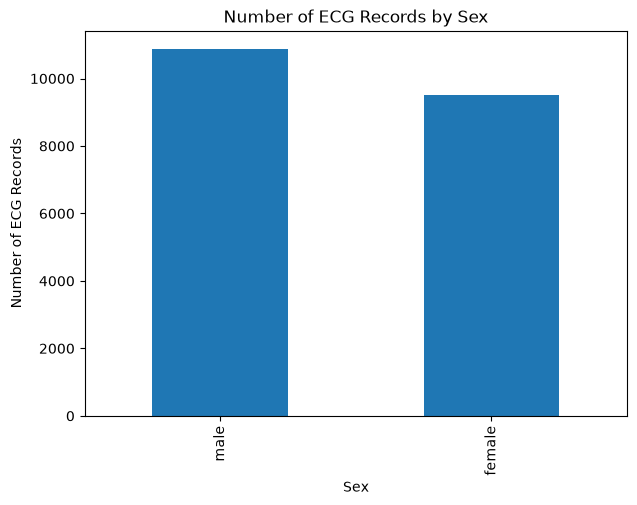

In [10]:
sex_counts.plot(kind='bar', figsize=(7,5))
plt.title('Number of ECG Records by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of ECG Records')
save("records_by_sex")
plt.show()

### EDA: Age Distribution

In [11]:
print(df.groupby("sex_label")["age"].describe())

             count       mean        std   min   25%   50%   75%   max
sex_label                                                             
female      9500.0  60.512211  16.135720  20.0  50.0  63.0  74.0  85.0
male       10870.0  58.880589  14.197025  20.0  51.0  60.0  69.0  85.0


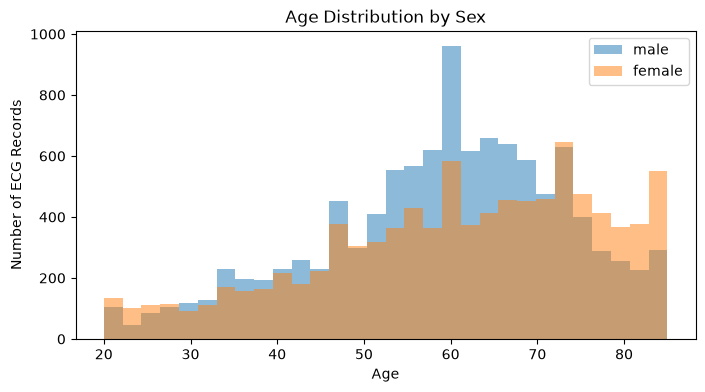

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["sex_label"] == "male"]["age"], bins=30, alpha=0.5, label="male")
plt.hist(df[df["sex_label"] == "female"]["age"], bins=30, alpha=0.5, label="female")
plt.title("Age Distribution by Sex")
plt.xlabel("Age")
plt.ylabel("Number of ECG Records")
plt.legend()
save("age_by_sex")
plt.show()

### EDA: Diagnosis Counts by Sex

           NORM    MI  STTC    CD   HYP
sex_label                              
female     4774  1802  2366  1638   990
male       4190  3291  2458  2826  1470


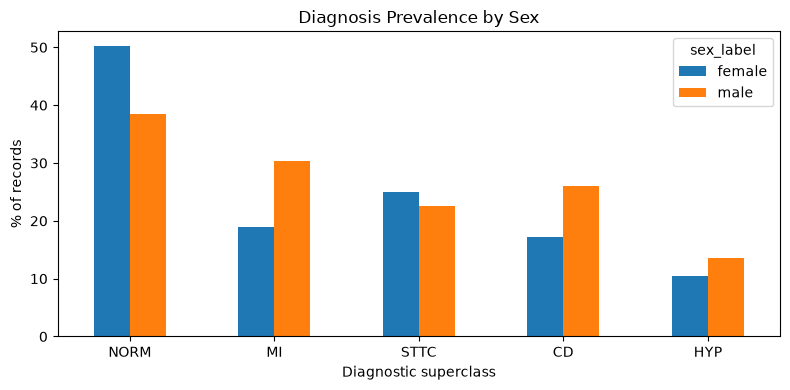

In [13]:
print(df.groupby("sex_label")[CLASSES].sum())

(df.groupby("sex_label")[CLASSES].mean() * 100).T.plot.bar(figsize=(8, 4), rot=0)
plt.title("Diagnosis Prevalence by Sex")
plt.xlabel("Diagnostic superclass"); plt.ylabel("% of records")
plt.tight_layout(); save("diagnosis_by_sex"); plt.show()

## Save Cleaned Data

In [14]:
df.to_pickle(PATH + "ptbxl_clean.pkl")
male_test.to_csv(PATH + "test_male.csv")
female_test.to_csv(PATH + "test_female.csv")
print("Saved", len(df), "cleaned records |", len(male_test), "male test |", len(female_test), "female test")

Saved 20370 cleaned records | 2177 male test | 1871 female test
